Dataset downloaded at:
C:\Users\hp\.cache\kagglehub\datasets\vbookshelf\respiratory-sound-database\versions\2

Audio folder selected:
C:\Users\hp\.cache\kagglehub\datasets\vbookshelf\respiratory-sound-database\versions\2\Respiratory_Sound_Database\Respiratory_Sound_Database\audio_and_txt_files

Number of wav files:
920

Number of txt files:
920


Reading txt annotations: 100%|██████████| 920/920 [00:11<00:00, 81.23it/s] 



Metadata created
Total respiratory cycles:
6898

First rows:
   start_time  end_time  crackles  wheezes            recording_id  \
0       0.036     0.579         0        0  101_1b1_Al_sc_Meditron   
1       0.579     2.450         0        0  101_1b1_Al_sc_Meditron   
2       2.450     3.893         0        0  101_1b1_Al_sc_Meditron   
3       3.893     5.793         0        0  101_1b1_Al_sc_Meditron   
4       5.793     7.521         0        0  101_1b1_Al_sc_Meditron   

   patient_id                                           wav_path  \
0         101  C:\Users\hp\.cache\kagglehub\datasets\vbookshe...   
1         101  C:\Users\hp\.cache\kagglehub\datasets\vbookshe...   
2         101  C:\Users\hp\.cache\kagglehub\datasets\vbookshe...   
3         101  C:\Users\hp\.cache\kagglehub\datasets\vbookshe...   
4         101  C:\Users\hp\.cache\kagglehub\datasets\vbookshe...   

                                            txt_path  duration  \
0  C:\Users\hp\.cache\kagglehub\datasets\v

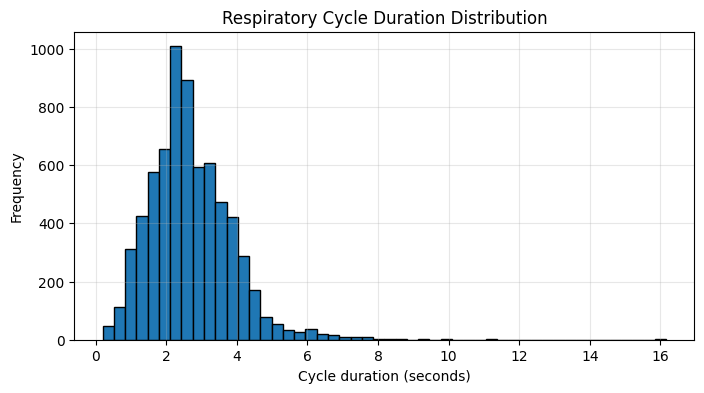

Checking audio files: 100%|██████████| 920/920 [00:02<00:00, 453.24it/s]



Audio info:
                         file  sample_rate  duration  channels
0  101_1b1_Al_sc_Meditron.wav        44100    20.000         1
1  101_1b1_Pr_sc_Meditron.wav        44100    20.000         1
2  102_1b1_Ar_sc_Meditron.wav        44100    20.000         1
3  103_2b2_Ar_mc_LittC2SE.wav        44100    20.000         1
4  104_1b1_Al_sc_Litt3200.wav         4000    15.856         1

Sample rate distribution:
sample_rate
4000      90
10000      6
44100    824
Name: count, dtype: int64

Parameters used
TARGET_SR: 4000
FIXED_DURATION: 5.0
TARGET_SAMPLES: 20000
N_MELS: 128
N_FFT: 512
HOP_LENGTH: 128
FMIN: 50
FMAX: 2000
TOP_DB: 80


Calculating Mel Spectrograms: 100%|██████████| 6898/6898 [01:40<00:00, 68.31it/s] 



Mel Spectrograms calculated
X_mel shape:
(6898, 128, 157)

y_binary shape:
(6898,)

y_multiclass shape:
(6898,)

Final class distribution:
class_label
normal      3642
crackles    1864
wheezes      886
both         506
Name: count, dtype: int64

Saved files:
respiratory_prepared_data\X_mel.npy
respiratory_prepared_data\y_binary.npy
respiratory_prepared_data\y_multiclass.npy
respiratory_prepared_data\metadata_valid.csv

Normal respiratory cycle example
Index: 4647
Recording ID: 178_1b6_Lr_mc_AKGC417L
Patient ID: 178
Start time: 5.375
End time: 7.756
Duration: 2.3810000000000002
Crackles: 0
Wheezes: 0
Binary anomaly: 0
Class label: normal
Mel shape: (128, 157)

Abnormal respiratory cycle example
Index: 3768
Recording ID: 166_1p1_Pr_sc_Meditron
Patient ID: 166
Start time: 33.448
End time: 36.855
Duration: 3.4069999999999965
Crackles: 0
Wheezes: 1
Binary anomaly: 1
Class label: wheezes
Mel shape: (128, 157)


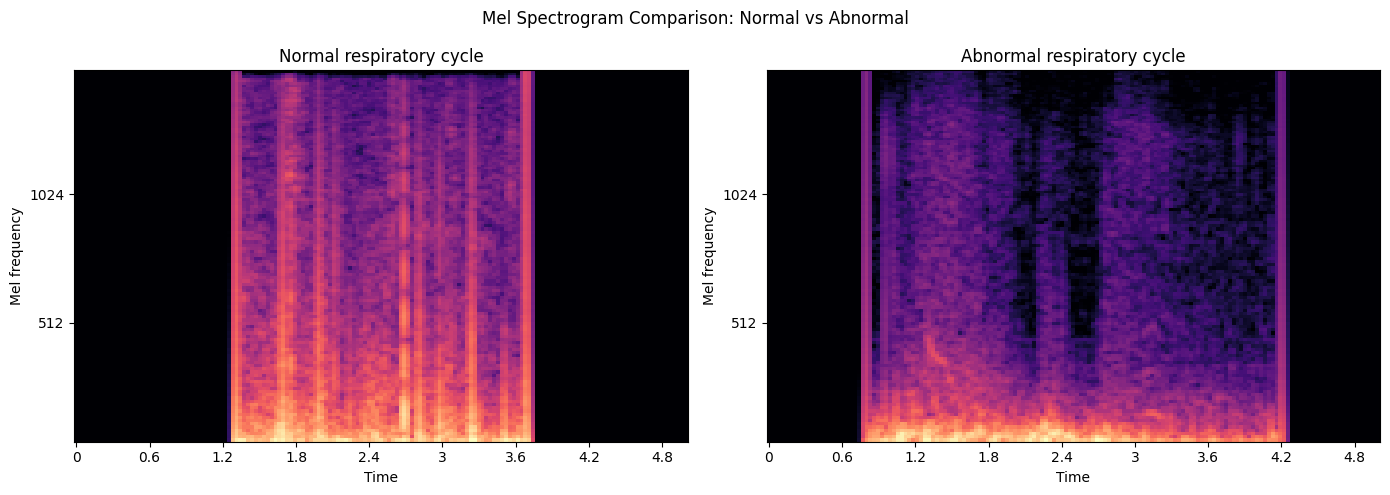

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf

from tqdm import tqdm
import kagglehub



# Descargar dataset

data = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")
Pathway = Path(data)

print("Dataset downloaded at:")
print(Pathway)


# Buscar carpeta con archivos .wav y .txt

audio_folder = None
max_wav_count = 0

for folder in Pathway.rglob("*"):
    if folder.is_dir():
        wav_count = len(list(folder.glob("*.wav")))
        txt_count = len(list(folder.glob("*.txt")))

        if wav_count > 0 and txt_count > 0:
            if wav_count > max_wav_count:
                max_wav_count = wav_count
                audio_folder = folder

print("\nAudio folder selected:")
print(audio_folder)

print("\nNumber of wav files:")
print(len(list(audio_folder.glob("*.wav"))))

print("\nNumber of txt files:")
print(len(list(audio_folder.glob("*.txt"))))


# Leer anotaciones .txt

all_annotations = []

txt_files = sorted(audio_folder.glob("*.txt"))

for txt_file in tqdm(txt_files, desc="Reading txt annotations"):

    df = pd.read_csv(
        txt_file,
        sep=r"\s+",
        header=None,
        names=["start_time", "end_time", "crackles", "wheezes"]
    )

    df["recording_id"] = txt_file.stem
    df["patient_id"] = df["recording_id"].str.split("_").str[0].astype(int)
    df["wav_path"] = str(txt_file.with_suffix(".wav"))
    df["txt_path"] = str(txt_file)
    df["duration"] = df["end_time"] - df["start_time"]

    df["binary_anomaly"] = (
        (df["crackles"] == 1) | (df["wheezes"] == 1)
    ).astype(int)

    class_labels = []

    for i in range(len(df)):
        crackles = df.loc[i, "crackles"]
        wheezes = df.loc[i, "wheezes"]

        if crackles == 0 and wheezes == 0:
            class_labels.append("normal")
        elif crackles == 1 and wheezes == 0:
            class_labels.append("crackles")
        elif crackles == 0 and wheezes == 1:
            class_labels.append("wheezes")
        else:
            class_labels.append("both")

    df["class_label"] = class_labels

    all_annotations.append(df)


metadata = pd.concat(all_annotations, ignore_index=True)

print("\nMetadata created")
print("Total respiratory cycles:")
print(len(metadata))

print("\nFirst rows:")
print(metadata.head())

print("\nClass distribution:")
print(metadata["class_label"].value_counts())

print("\nBinary anomaly distribution:")
print(metadata["binary_anomaly"].value_counts())


# Revisar duración de los ciclos

print("\nDuration statistics:")
print(metadata["duration"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(metadata["duration"], bins=50, edgecolor="black")
plt.xlabel("Cycle duration (seconds)")
plt.ylabel("Frequency")
plt.title("Respiratory Cycle Duration Distribution")
plt.grid(alpha=0.3)
plt.show()


# Revisar sample rates originales

wav_files = sorted(audio_folder.glob("*.wav"))

audio_info = []

for wav_file in tqdm(wav_files, desc="Checking audio files"):
    info = sf.info(wav_file)

    audio_info.append({
        "file": wav_file.name,
        "sample_rate": info.samplerate,
        "duration": info.duration,
        "channels": info.channels
    })

audio_info_df = pd.DataFrame(audio_info)

print("\nAudio info:")
print(audio_info_df.head())

print("\nSample rate distribution:")
print(audio_info_df["sample_rate"].value_counts().sort_index())


# Parámetros para Mel Spectrogram

TARGET_SR = 4000
FIXED_DURATION = 5.0
TARGET_SAMPLES = int(TARGET_SR * FIXED_DURATION)

N_MELS = 128
N_FFT = 512
HOP_LENGTH = 128

FMIN = 50
FMAX = 2000
TOP_DB = 80

print("\nParameters used")
print("TARGET_SR:", TARGET_SR)
print("FIXED_DURATION:", FIXED_DURATION)
print("TARGET_SAMPLES:", TARGET_SAMPLES)
print("N_MELS:", N_MELS)
print("N_FFT:", N_FFT)
print("HOP_LENGTH:", HOP_LENGTH)
print("FMIN:", FMIN)
print("FMAX:", FMAX)
print("TOP_DB:", TOP_DB)


# Calcular Mel Spectrograms para todos los ciclos
# No se imprimen todos, solo se guardan en X_mel

mel_list = []
valid_rows = []

for i, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Calculating Mel Spectrograms"):

    wav_path = row["wav_path"]
    start_time = float(row["start_time"])
    cycle_duration = float(row["duration"])

    y, sr = librosa.load(
        wav_path,
        sr=TARGET_SR,
        mono=True,
        offset=start_time,
        duration=cycle_duration
    )

    if len(y) == 0:
        continue

    y = librosa.util.normalize(y)

    current_samples = len(y)

    if current_samples < TARGET_SAMPLES:
        missing_samples = TARGET_SAMPLES - current_samples
        left_padding = missing_samples // 2
        right_padding = missing_samples - left_padding

        y_fixed = np.pad(
            y,
            (left_padding, right_padding),
            mode="constant"
        )

    elif current_samples > TARGET_SAMPLES:
        start_cut = (current_samples - TARGET_SAMPLES) // 2
        end_cut = start_cut + TARGET_SAMPLES

        y_fixed = y[start_cut:end_cut]

    else:
        y_fixed = y

    mel_power = librosa.feature.melspectrogram(
        y=y_fixed,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    mel_db = librosa.power_to_db(
        mel_power,
        ref=np.max,
        top_db=TOP_DB
    )

    mel_norm = (mel_db + TOP_DB) / TOP_DB
    mel_norm = np.clip(mel_norm, 0, 1)

    mel_list.append(mel_norm.astype(np.float32))
    valid_rows.append(i)


X_mel = np.array(mel_list, dtype=np.float32)

metadata_valid = metadata.loc[valid_rows].reset_index(drop=True)

y_binary = metadata_valid["binary_anomaly"].values
y_multiclass = metadata_valid["class_label"].values

print("\nMel Spectrograms calculated")
print("X_mel shape:")
print(X_mel.shape)

print("\ny_binary shape:")
print(y_binary.shape)

print("\ny_multiclass shape:")
print(y_multiclass.shape)

print("\nFinal class distribution:")
print(metadata_valid["class_label"].value_counts())


# Guardar datos preparados

output_folder = Path("respiratory_prepared_data")
output_folder.mkdir(exist_ok=True)

np.save(output_folder / "X_mel.npy", X_mel)
np.save(output_folder / "y_binary.npy", y_binary)
np.save(output_folder / "y_multiclass.npy", y_multiclass)

metadata_valid.to_csv(output_folder / "metadata_valid.csv", index=False)

print("\nSaved files:")
print(output_folder / "X_mel.npy")
print(output_folder / "y_binary.npy")
print(output_folder / "y_multiclass.npy")
print(output_folder / "metadata_valid.csv")


# Seleccionar un ciclo normal y un ciclo anómalo

normal_rows = metadata_valid[metadata_valid["binary_anomaly"] == 0]
abnormal_rows = metadata_valid[metadata_valid["binary_anomaly"] == 1]

normal_index = np.random.choice(normal_rows.index)
abnormal_index = np.random.choice(abnormal_rows.index)

normal_mel = X_mel[normal_index]
abnormal_mel = X_mel[abnormal_index]

normal_info = metadata_valid.iloc[normal_index]
abnormal_info = metadata_valid.iloc[abnormal_index]


print("\nNormal respiratory cycle example")
print("Index:", normal_index)
print("Recording ID:", normal_info["recording_id"])
print("Patient ID:", normal_info["patient_id"])
print("Start time:", normal_info["start_time"])
print("End time:", normal_info["end_time"])
print("Duration:", normal_info["duration"])
print("Crackles:", normal_info["crackles"])
print("Wheezes:", normal_info["wheezes"])
print("Binary anomaly:", normal_info["binary_anomaly"])
print("Class label:", normal_info["class_label"])
print("Mel shape:", normal_mel.shape)


print("\nAbnormal respiratory cycle example")
print("Index:", abnormal_index)
print("Recording ID:", abnormal_info["recording_id"])
print("Patient ID:", abnormal_info["patient_id"])
print("Start time:", abnormal_info["start_time"])
print("End time:", abnormal_info["end_time"])
print("Duration:", abnormal_info["duration"])
print("Crackles:", abnormal_info["crackles"])
print("Wheezes:", abnormal_info["wheezes"])
print("Binary anomaly:", abnormal_info["binary_anomaly"])
print("Class label:", abnormal_info["class_label"])
print("Mel shape:", abnormal_mel.shape)


# Graficar comparación normal vs anómalo

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

librosa.display.specshow(
    normal_mel,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmin=FMIN,
    fmax=FMAX,
    ax=axes[0]
)

axes[0].set_title("Normal respiratory cycle")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Mel frequency")


librosa.display.specshow(
    abnormal_mel,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmin=FMIN,
    fmax=FMAX,
    ax=axes[1]
)

axes[1].set_title("Abnormal respiratory cycle")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Mel frequency")

plt.suptitle("Mel Spectrogram Comparison: Normal vs Abnormal")
plt.tight_layout()
plt.show()

In [9]:
print("\nFinal class distribution:")
print(metadata_valid["class_label"].value_counts())


Final class distribution:
class_label
normal      3642
crackles    1864
wheezes      886
both         506
Name: count, dtype: int64


Starting feature extraction from respiratory cycles...
Total cycles available:
6898


Extracting acoustic features:   1%|          | 35/6898 [00:02<08:09, 14.01it/s]c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1484
  warnings.warn(
Extracting acoustic features:   6%|▌         | 395/6898 [00:12<02:09, 50.38it/s]c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1847
  warnings.warn(
Extracting acoustic features:   9%|▉         | 634/6898 [00:18<03:02, 34.38it/s]c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1316
  warnings.warn(
Extracting acoustic features:  10%|▉         | 656/6898 [00:19<01:56, 53.36it/s]c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048


Feature dataset created
Shape:
(6898, 43)

First rows:
   patient_id            recording_id  duration  mfcc_1_mean  mfcc_1_std  \
0         101  101_1b1_Al_sc_Meditron     0.543  -233.955414   56.143593   
1         101  101_1b1_Al_sc_Meditron     1.871  -291.569519   48.911472   
2         101  101_1b1_Al_sc_Meditron     1.443  -292.376495   62.907879   
3         101  101_1b1_Al_sc_Meditron     1.900  -295.806000   67.899879   
4         101  101_1b1_Al_sc_Meditron     1.728  -293.771027   50.288002   

   mfcc_2_mean  mfcc_2_std  mfcc_3_mean  mfcc_3_std  mfcc_4_mean  ...  \
0   130.069977   32.303410    59.026508   15.914005    45.732460  ...   
1   159.152512   23.333395    70.454506   12.083428    53.103466  ...   
2   153.404526   28.364452    61.730534    6.311884    55.087860  ...   
3   158.627884   29.606279    68.694412   11.411888    51.999977  ...   
4   164.395554   31.526487    67.843018   10.241482    51.360241  ...   

   spectral_centroid_mean  spectral_centroid_std

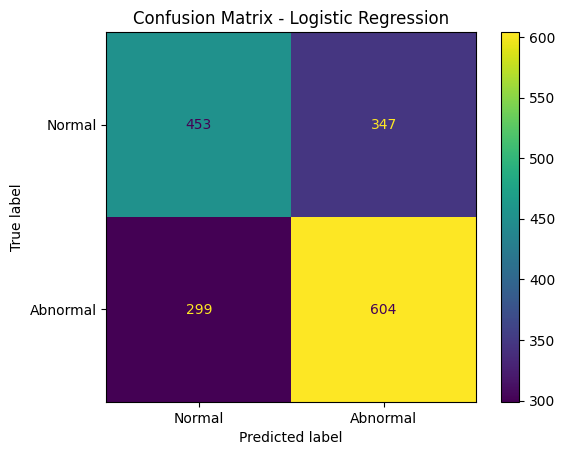


Training Random Forest model...

RANDOM FOREST RESULTS
Accuracy:
0.5948326482677627
Precision:
0.6573116691285081
Recall:
0.49280177187153934
F1-score:
0.5632911392405063
ROC-AUC:
0.6321650055370986

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.71      0.62       800
           1       0.66      0.49      0.56       903

    accuracy                           0.59      1703
   macro avg       0.61      0.60      0.59      1703
weighted avg       0.61      0.59      0.59      1703


Confusion matrix:
[[568 232]
 [458 445]]


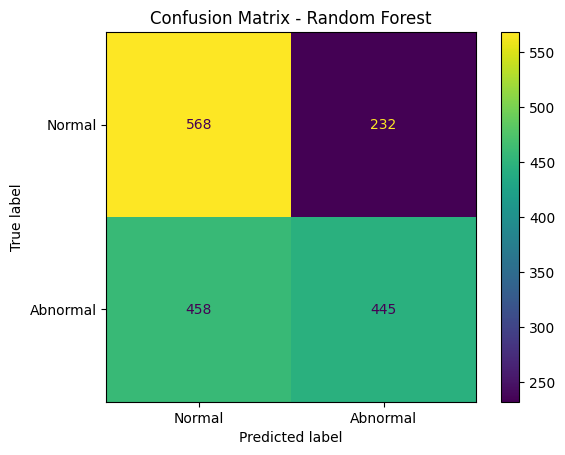


Creating metrics comparison table...

MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.620669   0.635121  0.668882  0.651564  0.630957
1        Random Forest  0.594833   0.657312  0.492802  0.563291  0.632165

Metrics table saved at:
respiratory_prepared_data\metrics_table.csv


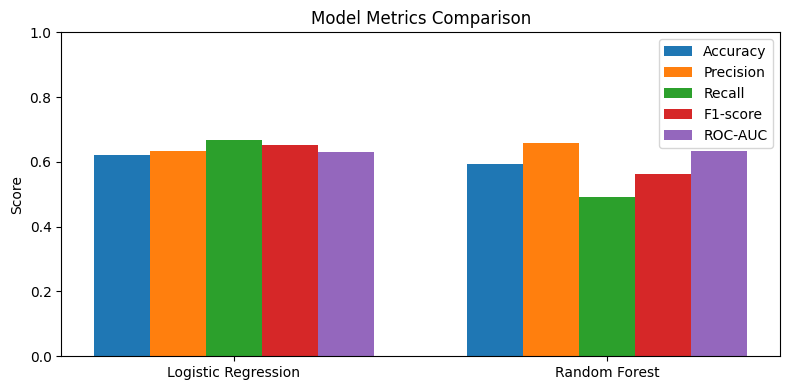

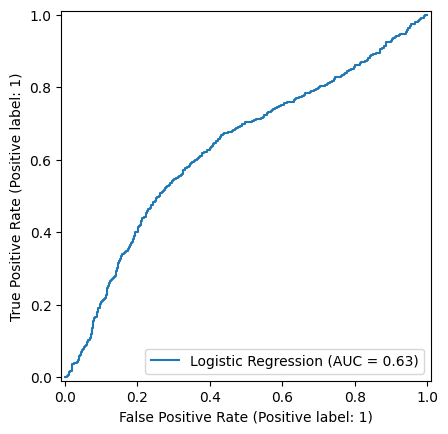

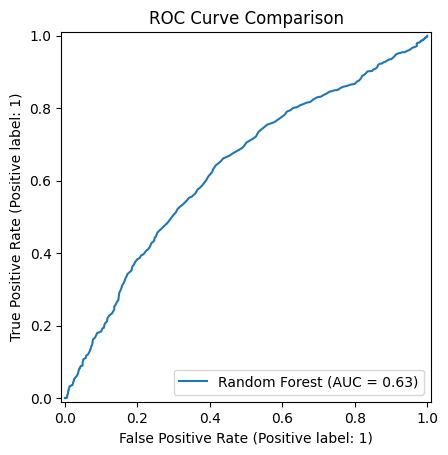


Calculating Random Forest feature importance...

Top 15 Random Forest important features:
                   feature  importance
0                 duration    0.051099
29                zcr_mean    0.037723
25            mfcc_13_mean    0.036085
13             mfcc_7_mean    0.032384
32   spectral_centroid_std    0.032278
7              mfcc_4_mean    0.031784
21            mfcc_11_mean    0.031441
19            mfcc_10_mean    0.029352
9              mfcc_5_mean    0.029091
1              mfcc_1_mean    0.028091
30                 zcr_std    0.027506
2               mfcc_1_std    0.027306
10              mfcc_5_std    0.026863
15             mfcc_8_mean    0.026820
31  spectral_centroid_mean    0.026328

Random Forest feature importance saved at:
respiratory_prepared_data\random_forest_feature_importance.csv


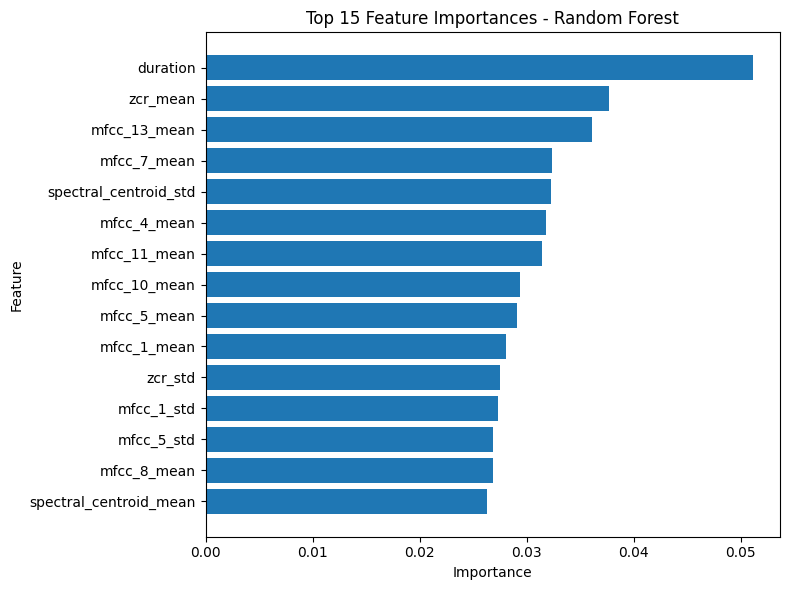


Calculating Logistic Regression coefficients...

Top 15 Logistic Regression influential features:
                    feature  coefficient  absolute_coefficient
3               mfcc_2_mean     0.762562              0.762562
7               mfcc_4_mean     0.613660              0.613660
33  spectral_bandwidth_mean     0.428944              0.428944
35    spectral_rolloff_mean    -0.302503              0.302503
10               mfcc_5_std    -0.274697              0.274697
25             mfcc_13_mean    -0.248592              0.248592
30                  zcr_std     0.198575              0.198575
2                mfcc_1_std    -0.197713              0.197713
28                  rms_std     0.190021              0.190021
1               mfcc_1_mean     0.189897              0.189897
13              mfcc_7_mean     0.177129              0.177129
4                mfcc_2_std    -0.151652              0.151652
9               mfcc_5_mean     0.146951              0.146951
24              mfc

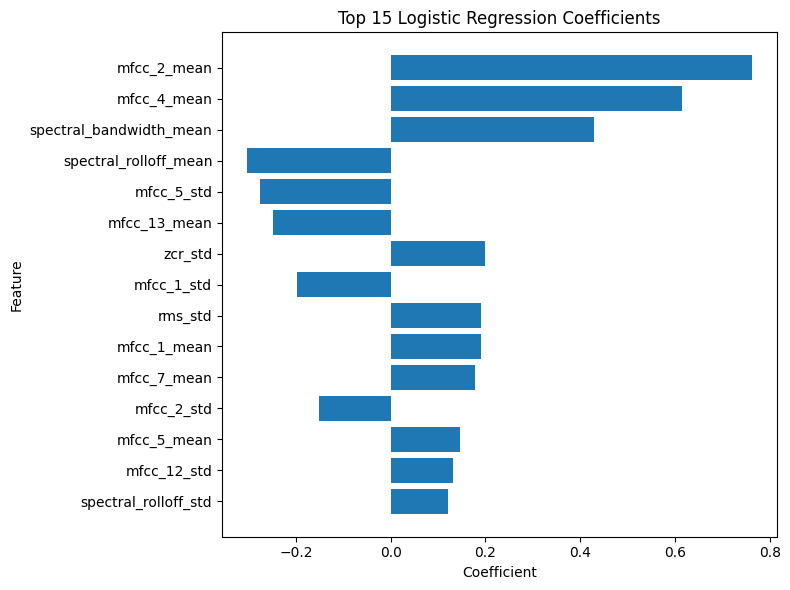


Process completed.
Generated files:
respiratory_prepared_data\features_dataset.csv
respiratory_prepared_data\metrics_table.csv
respiratory_prepared_data\random_forest_feature_importance.csv
respiratory_prepared_data\logistic_regression_coefficients.csv


In [10]:
# Desde aquí empezamos el desarrollo del modelo y métricas
# Se asume que ya existen: metadata_valid y TARGET_SR

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm


print("Starting feature extraction from respiratory cycles...")
print("Total cycles available:")
print(len(metadata_valid))


feature_rows = []

for i, row in tqdm(metadata_valid.iterrows(), total=len(metadata_valid), desc="Extracting acoustic features"):

    wav_path = row["wav_path"]
    start_time = float(row["start_time"])
    cycle_duration = float(row["duration"])

    y, sr = librosa.load(
        wav_path,
        sr=TARGET_SR,
        mono=True,
        offset=start_time,
        duration=cycle_duration
    )

    if len(y) == 0:
        continue

    y = librosa.util.normalize(y)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=TARGET_SR,
        n_mfcc=13
    )

    rms = librosa.feature.rms(y=y)

    zcr = librosa.feature.zero_crossing_rate(y)

    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=TARGET_SR
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=TARGET_SR
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=TARGET_SR
    )

    row_features = {}

    row_features["patient_id"] = row["patient_id"]
    row_features["recording_id"] = row["recording_id"]
    row_features["duration"] = row["duration"]

    row_features["mfcc_1_mean"] = np.mean(mfcc[0])
    row_features["mfcc_1_std"] = np.std(mfcc[0])
    row_features["mfcc_2_mean"] = np.mean(mfcc[1])
    row_features["mfcc_2_std"] = np.std(mfcc[1])
    row_features["mfcc_3_mean"] = np.mean(mfcc[2])
    row_features["mfcc_3_std"] = np.std(mfcc[2])
    row_features["mfcc_4_mean"] = np.mean(mfcc[3])
    row_features["mfcc_4_std"] = np.std(mfcc[3])
    row_features["mfcc_5_mean"] = np.mean(mfcc[4])
    row_features["mfcc_5_std"] = np.std(mfcc[4])
    row_features["mfcc_6_mean"] = np.mean(mfcc[5])
    row_features["mfcc_6_std"] = np.std(mfcc[5])
    row_features["mfcc_7_mean"] = np.mean(mfcc[6])
    row_features["mfcc_7_std"] = np.std(mfcc[6])
    row_features["mfcc_8_mean"] = np.mean(mfcc[7])
    row_features["mfcc_8_std"] = np.std(mfcc[7])
    row_features["mfcc_9_mean"] = np.mean(mfcc[8])
    row_features["mfcc_9_std"] = np.std(mfcc[8])
    row_features["mfcc_10_mean"] = np.mean(mfcc[9])
    row_features["mfcc_10_std"] = np.std(mfcc[9])
    row_features["mfcc_11_mean"] = np.mean(mfcc[10])
    row_features["mfcc_11_std"] = np.std(mfcc[10])
    row_features["mfcc_12_mean"] = np.mean(mfcc[11])
    row_features["mfcc_12_std"] = np.std(mfcc[11])
    row_features["mfcc_13_mean"] = np.mean(mfcc[12])
    row_features["mfcc_13_std"] = np.std(mfcc[12])

    row_features["rms_mean"] = np.mean(rms)
    row_features["rms_std"] = np.std(rms)

    row_features["zcr_mean"] = np.mean(zcr)
    row_features["zcr_std"] = np.std(zcr)

    row_features["spectral_centroid_mean"] = np.mean(spectral_centroid)
    row_features["spectral_centroid_std"] = np.std(spectral_centroid)

    row_features["spectral_bandwidth_mean"] = np.mean(spectral_bandwidth)
    row_features["spectral_bandwidth_std"] = np.std(spectral_bandwidth)

    row_features["spectral_rolloff_mean"] = np.mean(spectral_rolloff)
    row_features["spectral_rolloff_std"] = np.std(spectral_rolloff)

    row_features["crackles"] = row["crackles"]
    row_features["wheezes"] = row["wheezes"]
    row_features["binary_anomaly"] = row["binary_anomaly"]
    row_features["class_label"] = row["class_label"]

    feature_rows.append(row_features)


features_df = pd.DataFrame(feature_rows)

print("\nFeature dataset created")
print("Shape:")
print(features_df.shape)

print("\nFirst rows:")
print(features_df.head())

print("\nBinary class distribution:")
print(features_df["binary_anomaly"].value_counts())

print("\nClass label distribution:")
print(features_df["class_label"].value_counts())


output_folder = Path("respiratory_prepared_data")
output_folder.mkdir(exist_ok=True)

features_df.to_csv(output_folder / "features_dataset.csv", index=False)

print("\nFeature dataset saved at:")
print(output_folder / "features_dataset.csv")


print("\nPreparing variables for the models...")

X = features_df.drop(
    columns=[
        "patient_id",
        "recording_id",
        "crackles",
        "wheezes",
        "binary_anomaly",
        "class_label"
    ]
)

y = features_df["binary_anomaly"]
groups = features_df["patient_id"]

print("\nX shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)

print("\nFeature names:")
print(X.columns.tolist())


print("\nCreating train/test split by patient...")

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(splitter.split(X, y, groups))

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

print("\nTraining samples:")
print(X_train.shape[0])

print("\nTesting samples:")
print(X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


print("\nTraining Logistic Regression model...")

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)
recall_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)
f1_logistic = f1_score(y_test, y_pred_logistic, zero_division=0)

if len(np.unique(y_test)) == 2:
    auc_logistic = roc_auc_score(y_test, y_prob_logistic)
else:
    auc_logistic = np.nan


print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

print("Accuracy:")
print(accuracy_logistic)

print("Precision:")
print(precision_logistic)

print("Recall:")
print(recall_logistic)

print("F1-score:")
print(f1_logistic)

print("ROC-AUC:")
print(auc_logistic)

print("\nClassification report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("\nConfusion matrix:")
print(cm_logistic)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Normal", "Abnormal"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()


print("\nTraining Random Forest model...")

forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)
y_prob_forest = forest_model.predict_proba(X_test)[:, 1]

accuracy_forest = accuracy_score(y_test, y_pred_forest)
precision_forest = precision_score(y_test, y_pred_forest, zero_division=0)
recall_forest = recall_score(y_test, y_pred_forest, zero_division=0)
f1_forest = f1_score(y_test, y_pred_forest, zero_division=0)

if len(np.unique(y_test)) == 2:
    auc_forest = roc_auc_score(y_test, y_prob_forest)
else:
    auc_forest = np.nan


print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")

print("Accuracy:")
print(accuracy_forest)

print("Precision:")
print(precision_forest)

print("Recall:")
print(recall_forest)

print("F1-score:")
print(f1_forest)

print("ROC-AUC:")
print(auc_forest)

print("\nClassification report:")
print(classification_report(y_test, y_pred_forest, zero_division=0))

cm_forest = confusion_matrix(y_test, y_pred_forest)

print("\nConfusion matrix:")
print(cm_forest)

ConfusionMatrixDisplay(
    confusion_matrix=cm_forest,
    display_labels=["Normal", "Abnormal"]
).plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()


print("\nCreating metrics comparison table...")

metrics_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_forest
    ],
    "Precision": [
        precision_logistic,
        precision_forest
    ],
    "Recall": [
        recall_logistic,
        recall_forest
    ],
    "F1-score": [
        f1_logistic,
        f1_forest
    ],
    "ROC-AUC": [
        auc_logistic,
        auc_forest
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
print(metrics_table)

metrics_table.to_csv(output_folder / "metrics_table.csv", index=False)

print("\nMetrics table saved at:")
print(output_folder / "metrics_table.csv")


plt.figure(figsize=(8, 4))

x = np.arange(len(metrics_table["Model"]))
width = 0.15

plt.bar(x - 2*width, metrics_table["Accuracy"], width, label="Accuracy")
plt.bar(x - width, metrics_table["Precision"], width, label="Precision")
plt.bar(x, metrics_table["Recall"], width, label="Recall")
plt.bar(x + width, metrics_table["F1-score"], width, label="F1-score")
plt.bar(x + 2*width, metrics_table["ROC-AUC"], width, label="ROC-AUC")

plt.xticks(x, metrics_table["Model"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Metrics Comparison")
plt.legend()
plt.tight_layout()
plt.show()


if len(np.unique(y_test)) == 2:

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob_logistic,
        name="Logistic Regression"
    )

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob_forest,
        name="Random Forest"
    )

    plt.title("ROC Curve Comparison")
    plt.show()

else:
    print("\nROC curve was not plotted because the test set does not contain both classes.")


print("\nCalculating Random Forest feature importance...")

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": forest_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 15 Random Forest important features:")
print(importance_df.head(15))

importance_df.to_csv(output_folder / "random_forest_feature_importance.csv", index=False)

print("\nRandom Forest feature importance saved at:")
print(output_folder / "random_forest_feature_importance.csv")

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"].head(15)[::-1],
    importance_df["importance"].head(15)[::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()


print("\nCalculating Logistic Regression coefficients...")

logistic_classifier = logistic_model.named_steps["classifier"]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logistic_classifier.coef_[0]
})

coef_df["absolute_coefficient"] = np.abs(coef_df["coefficient"])

coef_df = coef_df.sort_values(
    by="absolute_coefficient",
    ascending=False
)

print("\nTop 15 Logistic Regression influential features:")
print(coef_df.head(15))

coef_df.to_csv(output_folder / "logistic_regression_coefficients.csv", index=False)

print("\nLogistic Regression coefficients saved at:")
print(output_folder / "logistic_regression_coefficients.csv")

plt.figure(figsize=(8, 6))
plt.barh(
    coef_df["feature"].head(15)[::-1],
    coef_df["coefficient"].head(15)[::-1]
)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Logistic Regression Coefficients")
plt.tight_layout()
plt.show()


print("\nProcess completed.")
print("Generated files:")
print(output_folder / "features_dataset.csv")
print(output_folder / "metrics_table.csv")
print(output_folder / "random_forest_feature_importance.csv")
print(output_folder / "logistic_regression_coefficients.csv")